<a href="https://colab.research.google.com/github/sinhaanshuk1712-alt/demographic-shift-econometrics/blob/main/world_project_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Demographic Shift & Labor Interdependency
### An Econometric Analysis of South Asia and Japan (1990–2024)
This project analyzes the macroeconomic relationship between shifting working-age populations and GDP growth using live API data from the World Bank.

In [5]:
!pip install wbgapi
import wbgapi as wb
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Define Target Regions: Japan (JPN) and South Asia (SAS)
countries = ['JPN', 'SAS']

# 2. Extract Working-Age Population (% of total) - SP.POP.1564.TO.ZS
df_pop = wb.data.DataFrame('SP.POP.1564.TO.ZS', countries, time=range(1990, 2025), numericTimeKeys=True)

# 3. Extract GDP per capita (constant 2015 US$) - NY.GDP.PCAP.KD
df_gdp = wb.data.DataFrame('NY.GDP.PCAP.KD', countries, time=range(1990, 2025), numericTimeKeys=True)

In [6]:
# Transpose so years become rows, then clean column names
df_pop = df_pop.T.rename(columns={'JPN': 'JPN_Working_Age_Pct', 'SAS': 'SAS_Working_Age_Pct'})
df_gdp = df_gdp.T.rename(columns={'JPN': 'JPN_GDP_Per_Capita', 'SAS': 'SAS_GDP_Per_Capita'})

# Merge both datasets on the Year index
df_merged = pd.concat([df_pop, df_gdp], axis=1)

# Drop missing values to ensure statistical stability
df_merged.dropna(inplace=True)
df_merged.head()

economy,JPN_Working_Age_Pct,SAS_Working_Age_Pct,JPN_GDP_Per_Capita,SAS_GDP_Per_Capita
1990,69.819770,57.021779,28904.765886,543.339636
1991,69.961322,57.240059,29775.391652,539.975756
1992,69.984734,57.475737,29916.652996,557.346083
1993,69.956333,57.721652,29665.387102,572.217189
1994,69.864102,57.979944,29876.454753,596.466356


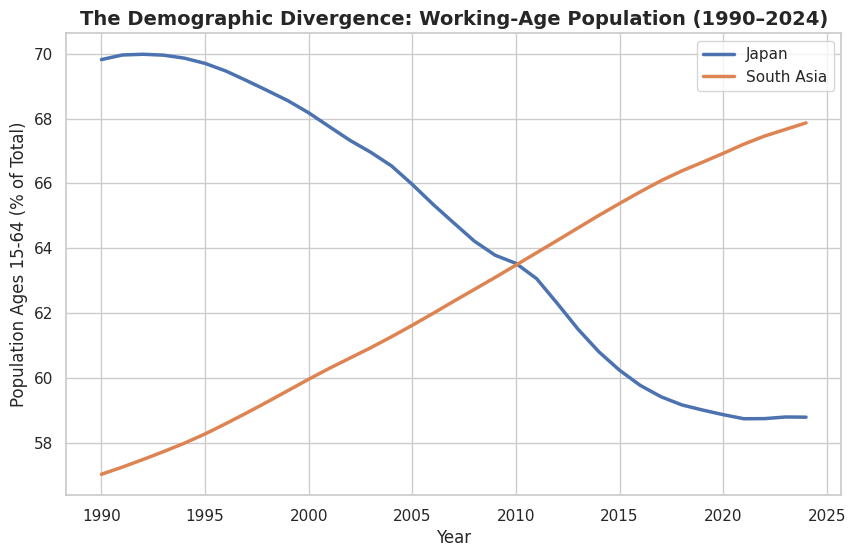

In [7]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot Working-Age Population Trends
sns.lineplot(data=df_merged, x=df_merged.index, y='JPN_Working_Age_Pct', label='Japan', linewidth=2.5)
sns.lineplot(data=df_merged, x=df_merged.index, y='SAS_Working_Age_Pct', label='South Asia', linewidth=2.5)

plt.title('The Demographic Divergence: Working-Age Population (1990–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Population Ages 15-64 (% of Total)', fontsize=12)
plt.legend()
plt.show()

In [8]:
# Take the natural log of GDP to measure percentage growth
df_merged['JPN_Log_GDP'] = np.log(df_merged['JPN_GDP_Per_Capita'])

# Define X (Independent Variable) and y (Dependent Variable)
X = df_merged['JPN_Working_Age_Pct']
y = df_merged['JPN_Log_GDP']

# Add a constant (beta_0) to the model
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Print the econometric summary
print("=== Ordinary Least Squares (OLS) Regression Results ===")
print(model.summary())

=== Ordinary Least Squares (OLS) Regression Results ===
                            OLS Regression Results                            
Dep. Variable:            JPN_Log_GDP   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     352.8
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           3.45e-19
Time:                        19:18:51   Log-Likelihood:                 82.872
No. Observations:                  35   AIC:                            -161.7
Df Residuals:                      33   BIC:                            -158.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------